# Fase 1 — Exploración de extractores de embeddings

Compara los extractores LM (off-the-shelf) contra el **baseline tabular** de la Fase 0
(XGBoost-Cox sobre las 12 features crudas, test C-index ~0.755 = *la barra a superar*).

Para cada extractor evaluamos 3 conjuntos de features con la MISMA cabeza XGBoost-Cox y el
MISMO split congelado:
- **tab**  — las 100 columnas tabulares (Fase 0)
- **emb**  — solo el embedding del prompt leakage-safe
- **both** — `emb ⊕ tab` (concatenado) → mide *complementariedad*

Pregunta central: ¿`emb` supera a `tab`? y sobre todo ¿`both` > `tab` (el embedding aporta señal nueva)?

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS = REPO / "results"
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print("Repo   :", REPO)
print("Results:", RESULTS)

Repo   : /media/drive/daniela/Projects/EmbeddingBiomarker
Results: /media/drive/daniela/Projects/EmbeddingBiomarker/results


## 1. ¿Qué hay en `results/`?

Cada corrida persiste un JSON. Convención de nombres:
- `baseline_tabular.json` — Fase 0 (Cox-PH, RSF, XGBoost-Cox).
- `embedding_grid__<modelo>.json` — Fase 1, un archivo por extractor.

In [2]:
for p in sorted(RESULTS.glob("*.json")):
    print(f"{p.name:38s} {p.stat().st_size:>7d} B")

baseline_tabular.json                     1452 B
embedding_grid__medcpt.json               1568 B


## 2. Cargar resultados

In [3]:
baseline = json.loads((RESULTS / "baseline_tabular.json").read_text())
grids = {p.stem.replace("embedding_grid__", ""): json.loads(p.read_text())
         for p in sorted(RESULTS.glob("embedding_grid__*.json"))}
print("Modelos tabulares :", list(baseline["models"]))
print("Extractores (emb) :", list(grids))
for m, d in grids.items():
    print(f"   {m}: template={d.get('template_id')} pooling={d.get('pooling')} dim={d.get('emb_dim')}")

Modelos tabulares : ['coxph', 'rsf', 'xgboost_cox']
Extractores (emb) : ['medcpt']
   medcpt: template=ctx_v1 pooling=mean dim=768


## 3. Tabla larga (tidy) con todo

In [4]:
rows = []
for m, d in baseline["models"].items():
    rows.append({"source": "tabular", "model": m, "feature_set": "tab",
                 "pooling": None, "val": d["c_index"]["val"], "test": d["c_index"]["test"]})
for model, d in grids.items():
    for fs, r in d["feature_sets"].items():
        rows.append({"source": "embedding", "model": model, "feature_set": fs,
                     "pooling": d.get("pooling"),
                     "val": r["c_index"]["val"], "test": r["c_index"]["test"]})
df = pd.DataFrame(rows)
df.sort_values("test", ascending=False).reset_index(drop=True)

,source,model,feature_set,pooling,val,test
0,embedding,medcpt,tab,mean,0.7477,0.7549
1,tabular,xgboost_cox,tab,None,0.7477,0.7549
2,embedding,medcpt,both,mean,0.7479,0.7526
3,tabular,coxph,tab,None,0.7154,0.7306
4,embedding,medcpt,emb,mean,0.7109,0.7177
5,tabular,rsf,tab,None,0.6965,0.7040


## 4. ¿Superan los embeddings al tabular?

La barra es el XGBoost-Cox tabular. `emb−tab` < 0 → el embedding pierde.
`both−tab` ≈ 0 → no hay complementariedad (el embedding no añade nada).

In [5]:
TAB = baseline["models"]["xgboost_cox"]["c_index"]["test"]
print(f"Barra a superar (XGBoost-Cox tabular, test C-index): {TAB:.4f}\n")

piv = (df[df.source == "embedding"]
       .pivot_table(index="model", columns="feature_set", values="test"))
piv["emb-tab"] = piv["emb"] - TAB
piv["both-tab (complementariedad)"] = piv["both"] - TAB
piv

Barra a superar (XGBoost-Cox tabular, test C-index): 0.7549



feature_set,both,emb,tab,emb-tab,both-tab (complementariedad)
model,,,,,
medcpt,0.7526,0.7177,0.7549,-0.0372,-0.0024


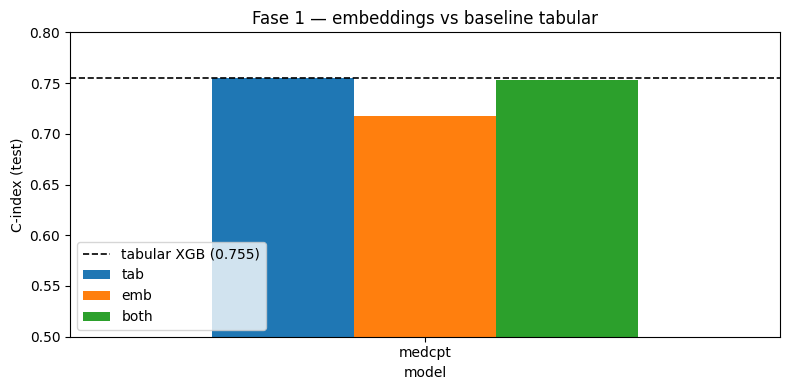

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
sub = df[df.source == "embedding"].pivot_table(index="model", columns="feature_set", values="test")
sub.reindex(columns=["tab", "emb", "both"]).plot.bar(ax=ax, width=0.75)
ax.axhline(TAB, ls="--", color="k", lw=1.2, label=f"tabular XGB ({TAB:.3f})")
ax.set_ylabel("C-index (test)")
ax.set_ylim(0.5, 0.8)
ax.set_title("Fase 1 — embeddings vs baseline tabular")
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Desempeño por tipo de cáncer (test)

In [7]:
pc_rows = []
for model, d in grids.items():
    for fs, r in d["feature_sets"].items():
        for ct, v in r.get("c_index_per_cancer_test", {}).items():
            pc_rows.append({"model": model, "feature_set": fs, "cancer": ct, "test": v})
# incluir tabular Fase 0 como referencia
for ct, v in baseline["models"]["xgboost_cox"]["c_index_per_cancer_test"].items():
    pc_rows.append({"model": "tabular(xgb)", "feature_set": "tab", "cancer": ct, "test": v})
pc = pd.DataFrame(pc_rows)
pc.pivot_table(index="cancer", columns=["model", "feature_set"], values="test")

model                      medcpt               tabular(xgb)
feature_set                  both    emb    tab          tab
cancer                                                      
Breast Cancer              0.7773 0.7463 0.7821       0.7821
Colorectal Cancer          0.7471 0.7135 0.7399       0.7399
Non-Small Cell Lung Cancer 0.7181 0.6601 0.7349       0.7349
Pancreatic Cancer          0.6640 0.6364 0.6494       0.6494
Prostate Cancer            0.7929 0.7635 0.7707       0.7707

## 6. Interpretación (estado actual)

- **MedCPT/mean**: `emb` (0.7177) **< tabular** (0.7549); `both` (0.7526) **no mejora** la barra.
  → El prompt es un *re-encoding lossy* de las mismas 12 features; MedCPT no aporta señal nueva.
- Por cáncer, el embedding solo es competitivo en próstata/mama, pero pierde fuerte en NSCLC y páncreas.

**Próximos extractores a llenar en la rejilla** (re-correr este notebook cuando aparezcan los JSON):
SmolLM-135M, y — si se resuelve el acceso *gated* + el costo CPU — MedGemma-4B, Llama-3.2-3B.
También variantes de pooling (`cls`, `last`) y templates de prompt más ricos.